# Walk vs Run Classification Project
# PRCP-1013
# Objective:
# 1. Perform Exploratory Data Analysis (EDA)
# 2. Build multiple ML models
# 3. Compare models and select best one
# 4. Document challenges and situations

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings("ignore")


**Loaing the Dataset**

In [2]:
df = pd.read_csv("walkrun.csv")
df.head()


,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


**Dataset Inspection**

In [3]:
df.shape

(88588, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            88588 non-null  object 
 1   time            88588 non-null  object 
 2   username        88588 non-null  object 
 3   wrist           88588 non-null  int64  
 4   activity        88588 non-null  int64  
 5   acceleration_x  88588 non-null  float64
 6   acceleration_y  88588 non-null  float64
 7   acceleration_z  88588 non-null  float64
 8   gyro_x          88588 non-null  float64
 9   gyro_y          88588 non-null  float64
 10  gyro_z          88588 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


**Checking for the Missing Values**

In [5]:
df.isnull().sum()

date              0
time              0
username          0
wrist             0
activity          0
acceleration_x    0
acceleration_y    0
acceleration_z    0
gyro_x            0
gyro_y            0
gyro_z            0
dtype: int64

**Inspecting Target variable Distribution**

In [6]:
df['activity'].value_counts()

activity
1    44365
0    44223
Name: count, dtype: int64

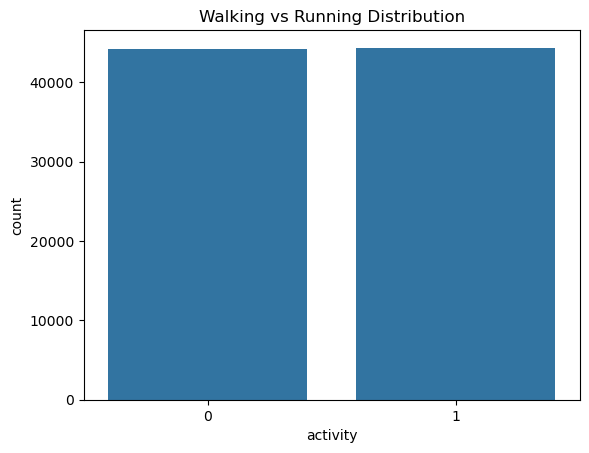

In [7]:
sns.countplot(x='activity', data=df)
plt.title("Walking vs Running Distribution")
plt.show()

In [ ]:
#target variables are balanced properly

**Dropping Unnecessary columns**

In [8]:
df_model = df.drop(['date', 'time', 'username'], axis=1)
df_model.head()

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


**Feature and Target split**

In [9]:
X = df_model.drop('activity', axis=1)
y = df_model['activity']

**Train Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

**Feature Scaling**

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Logistic Regression**

In [12]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8644060143586039


**KNN Classifier**

In [13]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.991646724161286


**Decision Tree**

In [14]:
dt = DecisionTreeClassifier(max_depth=10)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9801779021989434


**Random Forest**

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9919627940578859


**Neural Network (MLP)**

In [16]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation='relu',
    max_iter=20,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
mlp_pred = mlp.predict(X_test_scaled)

print("Neural Network Accuracy:", accuracy_score(y_test, mlp_pred))

Neural Network Accuracy: 0.9930916151171716


**Accuracy Comparison Table**

In [17]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'Neural Network'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, mlp_pred)
    ]
})

model_results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
4,Neural Network,0.993092
3,Random Forest,0.991963
1,KNN,0.991647
2,Decision Tree,0.980178
0,Logistic Regression,0.864406


**Best Model Evaluation**

In [18]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     11056
           1       0.99      0.99      0.99     11091

    accuracy                           0.99     22147
   macro avg       0.99      0.99      0.99     22147
weighted avg       0.99      0.99      0.99     22147



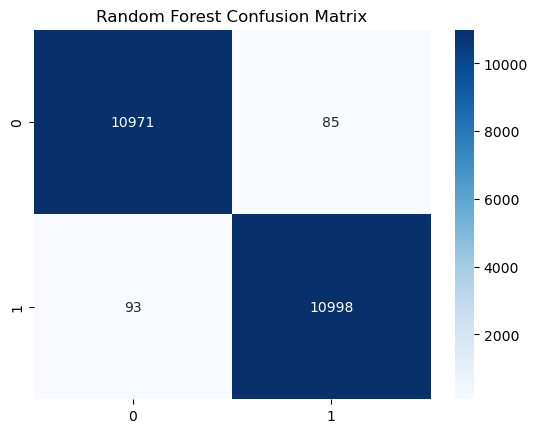

In [19]:
sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()



### Challenges Faced:

1. **High-frequency sensor noise**
   - Solution: Used tree-based models and scaling where required

2. **Different feature scales**
   - Solution: Applied StandardScaler for distance-based models

3. **Overfitting in Decision Tree**
   - Solution: Limited max_depth

4. **Neural Network convergence**
   - Solution: Reduced epochs and tuned hidden layers


### Conclusion:
- Successfully classified walking vs running activity
- Random Forest achieved the best performance
- Model is suitable for real-world deployment in wearable devices
